## Map matching using Valhalla 
References:
- useful [guide](https://gis-ops.com/valhalla-how-to-run-with-docker-on-ubuntu/) to run Valhalla with Docker
- [Towards Data Science](https://towardsdatascience.com/map-matching-done-right-using-valhallas-meili-f635ebd17053) article
- [Medium](https://medium.com/@hernandezgalaviz/using-valhalla-map-matching-to-get-route-and-travelled-distance-from-raw-gps-points-4ea6b1c88a4c) article

In [1]:
import pandas as pd
import geopandas as gpd
import json
import requests
from shapely.geometry.linestring import LineString, Point
import folium

In [2]:
df = pd.read_parquet("../data/trips_pointv3_cleaned.parquet")
# try with a single trip
df = df[df.unique_id=='24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07']
# sort pts by order in time
df = df.sort_values(by=['point_timestamp'])
# geodataframe
df = gpd.GeoDataFrame(
    df,
    crs='EPSG:4326',
    geometry=gpd.points_from_xy(df.point_longitude, df.point_latitude))

In [3]:
trip_linestring = LineString(df.geometry.to_list()) # linestring of the trip

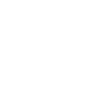

In [4]:
trip_linestring

In [5]:
# all points in the trip
gdf_points_temp = df.apply(lambda x: [y for y in x['geometry'].coords], axis=1)
gdf_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy([a_tuple[0] for a_tuple in gdf_points_temp[0]], [a_tuple[1] for a_tuple in gdf_points_temp[0]]), crs=4326)

# geodataframe of linestring and pts
gdf = gpd.GeoDataFrame(pd.concat([df, gdf_points], ignore_index=True))

In [6]:
# dataframe with pts lat and long (for the single trip chosen)
df_points = pd.DataFrame({'lon':df.point_longitude, 'lat':df.point_latitude})
df_points.head(3)


,lon,lat
1449,11.118389,46.054911
1450,11.118389,46.054911
1451,11.119268,46.054611


In [7]:
# request
meili_coordinates = df_points.to_json(orient='records')
meili_head = '{"shape":'
meili_tail = ""","search_radius": 300, "shape_match":"map_snap", "costing":"bicycle", "format":"osrm"}"""
# https://github.com/valhalla/valhalla-docs/blob/master/turn-by-turn/api-reference.md
# search radius -> distance to look between points and road network; costing -> auto, bicycle, ...
meili_request_body = meili_head + meili_coordinates + meili_tail
url = "http://localhost:8002/trace_route"
# curl http://localhost:8002/route --data '{"locations":[{"lat":48.632608,"lon":9.010350,"type":"break"},{"lat":48.631776,"lon":9.011528,"type":"break"}],"costing":"auto","directions_options":{"units":"miles"}}' | jq '.'
headers = {'Content-type': 'application/json'}
data = str(meili_request_body)
r = requests.post(url, data=data, headers=headers)

In [9]:
response_text = r.json()
response_text

{'matchings': [{'weight_name': 'bicycle',
   'weight': 1817.99,
   'duration': 372.156,
   'distance': 1385.282,
   'legs': [{'via_waypoints': [],
     'admins': [{}],
     'weight': 1817.99,
     'duration': 372.156,
     'steps': [{'intersections': [{'entry': [True],
         'bearings': [118],
         'duration': 30.239,
         'admin_index': 0,
         'out': 0,
         'weight': 37.119,
         'geometry_index': 0,
         'location': [11.118484, 46.055036]},
        {'entry': [True, False],
         'in': 1,
         'bearings': [172, 266],
         'duration': 5.4,
         'turn_weight': 18.575,
         'turn_duration': 4.0,
         'admin_index': 0,
         'out': 0,
         'weight': 20.626,
         'geometry_index': 7,
         'location': [11.12036, 46.054756]},
        {'entry': [True, False, False],
         'in': 2,
         'bearings': [174, 266, 352],
         'duration': 1.25,
         'turn_weight': 1.046,
         'turn_duration': 0.45,
         'admin_i

In [113]:
response_text['matchings'][0]['legs'][0]['summary'] # street name

'Via San Pio X, Via Luigi Einaudi'

In [114]:
response_text['matchings'][0]['legs'][0]['steps'][0]['maneuver'] 

{'type': 'depart',
 'instruction': 'Bike southeast on the cycleway.',
 'bearing_after': 118,
 'bearing_before': 0,
 'location': [11.118484, 46.055036]}

In [10]:
# get response
if r.status_code == 200:
    response_text = json.loads(r.text)
else:
    print('Error',r.status_code,':\n',r.text)
    raise ValueError
search_1 = response_text.get('matchings')
search_2 = dict(search_1[0])
poly = search_2.get('geometry')
search_3 = response_text.get('tracepoints')

In [53]:
poly # encoded polyline

'wf~yvAgxreTzD}NjCmMrBmPjAgQz@mQIyYI}DvBWjAKKuCrWmDxG_AhMkCpNgBb\\aFpB[z@jCpKa@rB`_@P`@`@D`@EUuFS_GWoNOiO?mDTwD^{Cp@mDb@aBH]`D_MVcAYSuA_AmLkI}IkHqGoFpAm@h@SvBwCL_BAyAWaQOwJg@o[tW@zL@`@?hAUb@M`AYPqLSuNi@gZb@sFSu@Io@Cu@AeAFoKB_C@oAHkPZkd@`@kG`AqGlFcSVqAn@yCt@yFPqDXoHE}Ja@cKw@}UaBoc@uAaLe@iCiAiFiCcImHoMqAgE{@kF}AuTe@aNEoHyFBuTAwCAsIF'

In [11]:
# decode function
def decode(encoded):
  '''
  The linestring is in an encoded polyline format: this function decodes it 
  '''
  inv = 1.0 / 1e6
  decoded = []
  previous = [0,0]
  i = 0
  #for each byte
  while i < len(encoded):
    #for each coord (lat, lon)
    ll = [0,0]
    for j in [0, 1]:
      shift = 0
      byte = 0x20
      #keep decoding bytes until you have this coord
      while byte >= 0x20:
        byte = ord(encoded[i]) - 63
        i += 1
        ll[j] |= (byte & 0x1f) << shift
        shift += 5
      #get the final value adding the previous offset and remember it for the next
      ll[j] = previous[j] + (~(ll[j] >> 1) if ll[j] & 1 else (ll[j] >> 1))
      previous[j] = ll[j]
    #scale by the precision and chop off long coords also flip the positions so
    #its the far more standard lon,lat instead of lat,lon
    decoded.append([float('%.6f' % (ll[1] * inv)), float('%.6f' % (ll[0] * inv))])
  #hand back the list of coordinates
  return decoded

In [56]:
decode(poly)[:5] # decoded into a list of lists with coordinates (to transform into linestring)

[[11.118484, 46.055036],
 [11.118739, 46.054942],
 [11.11897, 46.054872],
 [11.119249, 46.054814],
 [11.119541, 46.054776]]

In [12]:
lst_MapMatchingRoute = LineString(decode(poly))
gdf_MapMatchingRoute_linestring = gpd.GeoDataFrame(geometry=[lst_MapMatchingRoute], crs=4326)
gdf_MapMatchingRoute_points_temp = gdf_MapMatchingRoute_linestring.apply(lambda x: [y for y in x['geometry'].coords], axis=1)
gdf_MapMatchingRoute_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy([a_tuple[0] for a_tuple in gdf_MapMatchingRoute_points_temp[0]], [a_tuple[1] for a_tuple in gdf_MapMatchingRoute_points_temp[0]]), crs=4326)
gdf_MapMatchingRoute = gpd.GeoDataFrame(pd.concat([gdf_MapMatchingRoute_linestring, gdf_MapMatchingRoute_points], ignore_index=True))
df_mapmatchedGPS_points = pd.DataFrame(list([d['location'] for d in search_3 if 'location' in d]) , columns=['lon', 'lat'])
gdf_mapmatchedGPS_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df_mapmatchedGPS_points['lon'], df_mapmatchedGPS_points['lat']), crs=4326)

In [14]:
gdf = gdf.dropna() # a row with NaN is produced

In [38]:
gdf_geometry = gdf.drop(df.columns.difference(['geometry']), 1) # keep only geometry column

C:\Users\luisa\AppData\Local\Temp\ipykernel_17808\490552785.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  gdf_geometry = gdf.drop(df.columns.difference(['geometry']), 1)


In [50]:
from  folium import plugins

m = folium.Map([46.0666, 11.1333], tiles='cartodbdark_matter', zoom_start=14)
# original points:
folium.GeoJson(gdf_geometry, style_function=lambda x:{'color': 'red'}, marker=folium.CircleMarker(radius=4, weight=0, fill_color='red', fill_opacity=1), name='Original GPS Points').add_to(m)
folium.GeoJson(trip_linestring, style_function=lambda x:{'color': 'red'}, marker=folium.CircleMarker(radius=4, weight=0, fill_color='red', fill_opacity=1), name='Original Route').add_to(m)

# map matched:
folium.GeoJson(gdf_mapmatchedGPS_points, marker=folium.CircleMarker(radius=4, weight=0, fill_color='white', fill_opacity=1), name='Map-Matched Points').add_to(m)
folium.GeoJson(gdf_MapMatchingRoute, style_function=lambda x:{'color': 'green'}, marker=folium.CircleMarker(radius=4, weight=0, fill_color='green', fill_opacity=1), name='Map-Matched Route').add_to(m)
folium.LayerControl(position='topright', collapsed=False).add_to(m)
m.save('mapmatching.html')

In [49]:
m

In [57]:
# length of the trip (in meters)
from pyproj import Geod
geod = Geod(ellps="WGS84")
rawGPS_linestring_distance = geod.geometry_length(trip_linestring)
MapMatchingRoute_linestring_distance = geod.geometry_length(gdf_MapMatchingRoute_linestring['geometry'][0])
print('Distance using original data = ', f"{rawGPS_linestring_distance:,.0f}")
print('Distance of the map-matched route = ', f"{MapMatchingRoute_linestring_distance:,.0f}")

Distance using original data =  1,228
Distance of the map-matched route =  1,382


In [134]:
# add matched coordinates (and street name when available) to original dataframe

response_text = json.loads(r.text)

resp = str(response_text['tracepoints'])

resp = resp.replace("'waypoint_index': None", "'waypoint_index': '#'")
resp = resp.replace("None", "{'matchings_index': '#', 'name': '', 'waypoint_index': '#', 'alternatives_count': 0, 'distance': 0, 'location': [0.0, 0.0]}")

resp = resp.replace("'", '"')

resp = json.dumps(resp)
resp = json.loads(resp)
        
df_response = pd.read_json(resp)
df_response = df_response[['name', 'location']]
                
final_df = pd.merge(df, df_response, left_index=True, right_index=True)

In [135]:
final_df = final_df.rename(columns={"name": "street_name", "location":"matched_coords"})

In [136]:
final_df

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,date,unique_id,geometry,street_name,matched_coords
0,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:46:54+00:00,46.052974,11.120415,13,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1204149999999995 46.0529739999999990),,"[11.118484, 46.055036]"
1,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:04+00:00,46.052951,11.120469,14,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1204689999999999 46.0529510000000002),,"[11.118484, 46.055036]"
2,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:15+00:00,46.052905,11.120811,15,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1208109999999998 46.0529050000000026),,"[11.11932, 46.054805]"
3,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:24+00:00,46.052874,11.121122,16,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1211219999999997 46.0528740000000028),,"[11.119656, 46.054764]"
4,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:35+00:00,46.052732,11.121525,17,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1215250000000001 46.0527319999999989),,"[11.120129, 46.054749]"
5,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:44+00:00,46.053044,11.121877,18,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1218769999999996 46.0530439999999999),,"[11.120378, 46.054658]"
6,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:47:55+00:00,46.053155,11.122239,19,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1222390000000004 46.0531549999999967),Via San Pio X,"[11.120543, 46.054255]"
7,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:48:04+00:00,46.053186,11.122459,20,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1224589999999992 46.0531859999999966),Via San Pio X,"[11.120546, 46.054242]"
8,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:48:15+00:00,46.053119,11.122809,21,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1228090000000002 46.0531190000000024),Via San Pio X,"[11.120552, 46.054219]"
9,VENTO,Tier,24c83c4e-1e60-4b65-9100-8cf1550076df,2022-01-07 20:48:24+00:00,46.052845,11.122992,22,2022-01-07,24c83c4e-1e60-4b65-9100-8cf1550076df_2022-01-07,POINT (11.1229920000000000 46.0528449999999978),Via San Pio X,"[11.120581, 46.054098]"
